In [1]:
# Add project root (the folder that contains "src/") to sys.path
import sys
import time
from pathlib import Path

def add_project_root(marker_dir="src", max_hops=5):
    p = Path.cwd().resolve()
    for _ in range(max_hops):
        if (p / marker_dir).exists():
            sys.path.insert(0, str(p))
            print(f"[OK] Added to sys.path: {p}")
            return
        p = p.parent
    raise RuntimeError(f"Could not find '{marker_dir}' within {max_hops} parents from {Path.cwd()}")

add_project_root()  

[OK] Added to sys.path: D:\Data\Projects\Thesis\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
d:\Data\Projects\Thesis\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation\myenv\Lib\site-packages\transformers\image_processing_base.py:417: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'reduce_labels'
  image_processor = cls(**image_processor_dict)


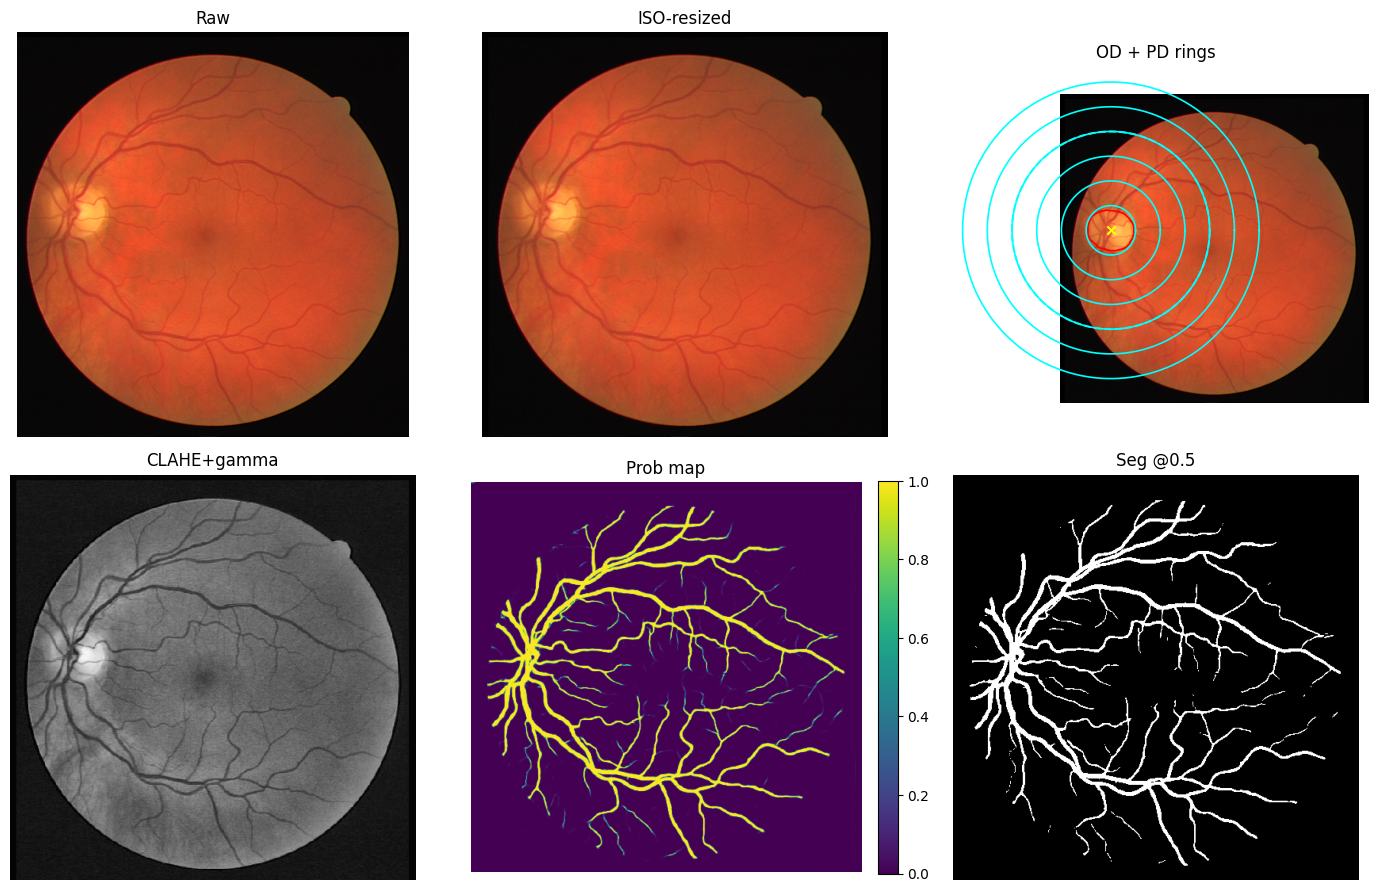

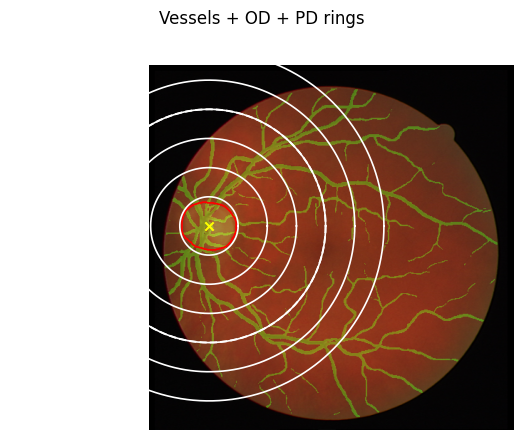

Metric,Value
Area density,0.083660
Length density (px^-1),0.027522
Fractal dimension,1.482572
Tortuosity (px^-2),0.184837
Tortuosity ×10⁻³ (per PD²),1240421.800
"Median width (px, orth)",4.500
"IQR width (px, orth)",3.500
Median width / PD,0.054932
IQR width / PD,0.042725
Length density · PD^2,184.699166


Topology,Value
Junctions,425
Endpoints,175
Junction density,0.001621
Endpoint density,0.000668
Angle p10,45.000
Angle p50,116.565
Angle p90,180.000
Angles ≤2PD: mean,110.376
Angles ≤2PD: std,47.568


Ring,Area dens,Len dens,FracDim,Median W,IQR W,Tortuosity ×10⁻³
0.0-0.5PD,0.390711,0.097327,1.023354,5.000,4.500,1132744.300
0.5-1.0PD,0.183480,0.052314,1.129948,5.000,3.000,1210861.000
1.0-1.5PD,0.122652,0.038856,1.100661,4.000,3.000,1229817.300
1.5-2.0PD,0.090817,0.031107,1.093687,4.000,2.000,1096759.100
2.0-2.5PD,0.088446,0.030603,1.073444,4.000,2.000,1196736.800
2.5-3.0PD,0.087695,0.028944,1.075058,4.000,2.000,1163499.200


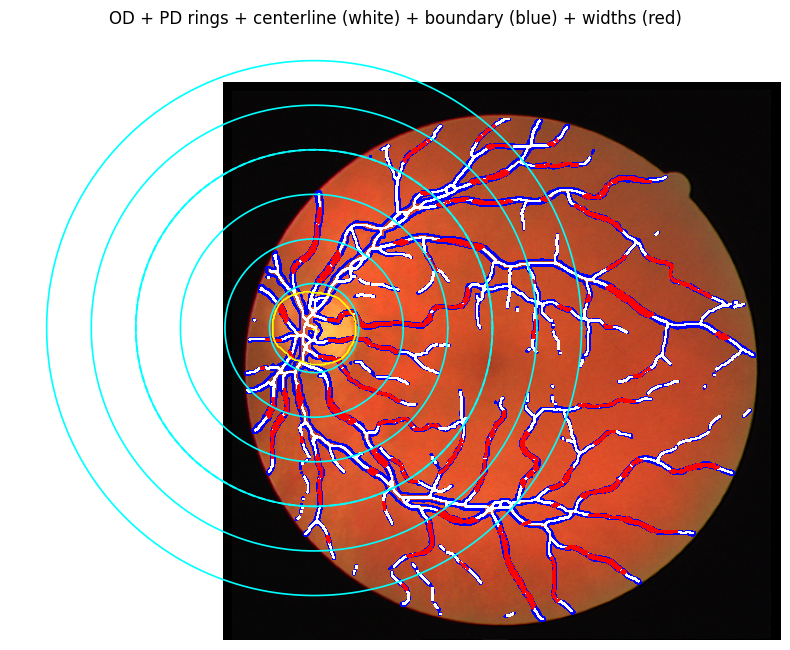

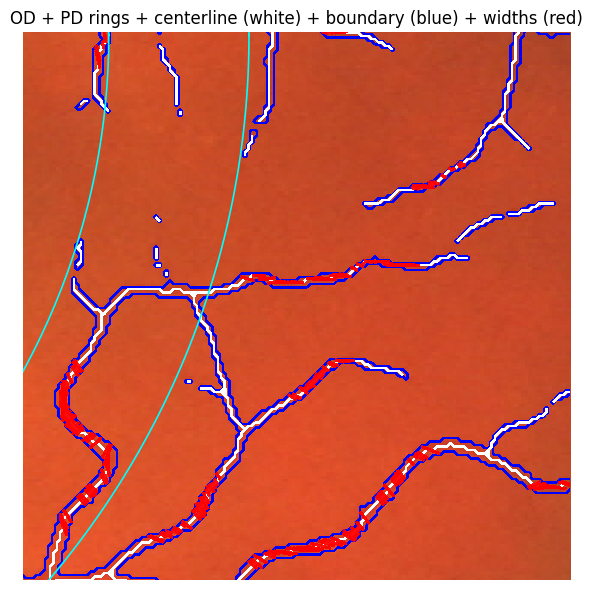

In [ ]:
from src.retina_biomarkers.notebook_utils.pipeline.config import PipelineConfig
from src.retina_biomarkers.notebook_utils.pipeline.retina import run_pipeline
from src.retina_biomarkers.notebook_utils.viz.overlays import visualize_grid, visualize_overlay, visualize_widths_centerline_boundary

# (1) INPUTS
ckpt_path  = "../../outputs/checkpoints/final/[DRIVE] dpcn_refineEdge.pth"
color_path = "../../data/raw/DRIVE/test/images/05_test.png"
fov_path   = None  # or path to an external FOV mask if you have one

cfg = PipelineConfig(image_size=512, threshold=0.5, use_fov_in_model=False)

# (2) RUN
out = run_pipeline(color_path, ckpt_path, fov_path=fov_path, cfg=cfg)

# (3) VISUALS
visualize_grid(out)
visualize_overlay(out)

# (4) METRIC TABLES
import pandas as pd
from IPython.display import display, HTML

bio = out["biomarkers"]; g = bio["global"]; t = bio["topology"]; rings = bio.get("rings") or {}

global_rows = [
    ("Area density",                 f"{g['area_density']:.6f}"),
    ("Length density (px^-1)",       f"{g['length_density_px_inv']:.6f}"),
    ("Fractal dimension",            f"{g['fractal_dimension']:.6f}"),
    ("Tortuosity (px^-2)",           f"{g['tortuosity_mean']:.6f}"),
    ("Tortuosity ×10⁻³ (per PD²)",  f"{g.get('tortuosity_mean_PD2_x1e3', float('nan')):.3f}"),
    ("Median width (px, orth)",      f"{g['vc_orth']['median_width']:.3f}"),
    ("IQR width (px, orth)",         f"{g['vc_orth']['iqr_width']:.3f}"),
    ("Median width / PD",            f"{g.get('median_width_PD', float('nan')):.6f}"),
    ("IQR width / PD",               f"{g.get('iqr_width_PD',    float('nan')):.6f}"),
    ("Length density · PD^2",        f"{g.get('length_density_PD_inv', float('nan')):.6f}"),
]
df_global = pd.DataFrame(global_rows, columns=["Metric", "Value"])

topo_rows = [
    ("Junctions",          int(t.get("junction_count", 0))),
    ("Endpoints",          int(t.get("endpoint_count", 0))),
    ("Junction density",   f"{t.get('junction_density', 0.0):.6f}"),
    ("Endpoint density",   f"{t.get('endpoint_density', 0.0):.6f}"),
    ("Angle p10",          f"{t.get('angle_p10', 0.0):.3f}"),
    ("Angle p50",          f"{t.get('angle_p50', 0.0):.3f}"),
    ("Angle p90",          f"{t.get('angle_p90', 0.0):.3f}"),
]
if isinstance(t.get("angles_2PD"), dict):
    a2 = t["angles_2PD"]
    topo_rows += [("Angles ≤2PD: mean", f"{a2.get('angle_mean', 0.0):.3f}"),
                  ("Angles ≤2PD: std",  f"{a2.get('angle_std', 0.0):.3f}")]
df_topo = pd.DataFrame(topo_rows, columns=["Topology", "Value"])

ring_rows = []
for ring_name, r in rings.items():
    ring_rows.append([
        ring_name,
        f"{r.get('area_density', 0.0):.6f}",
        f"{r.get('length_density', 0.0):.6f}",
        f"{r.get('fractal_dimension', 0.0):.6f}",
        f"{r.get('median_width', 0.0):.3f}",
        f"{r.get('iqr_width', 0.0):.3f}",
        f"{r.get('tortuosity_mean_PD2_x1e3', 0.0):.3f}",
    ])
df_rings = pd.DataFrame(ring_rows, columns=["Ring","Area dens","Len dens","FracDim","Median W","IQR W","Tortuosity ×10⁻³"])


# full-frame view
_ = visualize_widths_centerline_boundary(
    out,
    # chord sampling knobs (optional, these are the defaults):
    stride_by_arc=1.0,
    margin_from_nodes=16.0,
    step=0.25,
    max_radius=20.0,
    clip_k_edt=1.25,
    min_len=0.75,
    tan_win_px=11,
    use_pca=True,
    pca_radius_px=7,
    kappa_max=0.18,
    asym_max_ratio=1.6,
    # drawing knobs:
    chord_lw=1.5, center_lw=1.0, boundary_lw=1.0,
    ring_color="cyan",
    figsize=(8, 8),
)

# zoomed close-up (use OD center as reference if you like)
zoom_center = (int(out["od"]["center_yx"][0] + 80), int(out["od"]["center_yx"][1] + 260))
_ = visualize_widths_centerline_boundary(
    out,
    zoom=(zoom_center[0], zoom_center[1], 80),   # (cy, cx, radius_px)
    figsize=(6, 6),
)


display(HTML("<h3>Global Metrics</h3>")); display(df_global.style.hide(axis='index'))
display(HTML("<h3>Topology Metrics</h3>")); display(df_topo.style.hide(axis='index'))
display(HTML("<h3>Ring-wise Metrics</h3>")); display(df_rings.style.hide(axis='index'))




d:\Data\Projects\Thesis\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation\myenv\Lib\site-packages\transformers\image_processing_base.py:417: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'reduce_labels'
  image_processor = cls(**image_processor_dict)


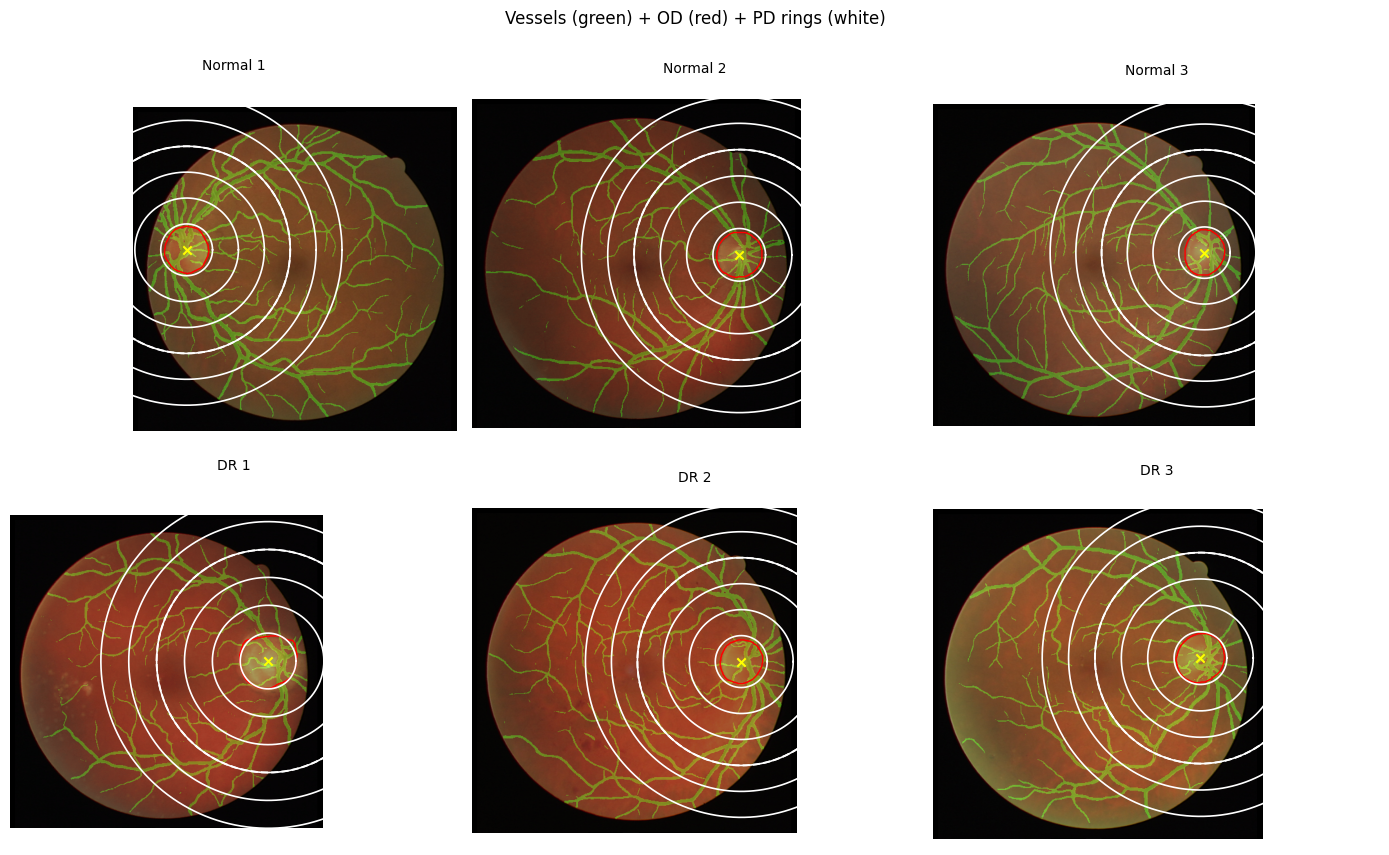

,Normal_mean,Normal_sd,DR_mean,DR_sd,Δ (DR-Norm),%Δ vs Norm
area_density,9.150000e-02,0.0110,8.140000e-02,0.0058,-0.0101,-11.0342
length_density_PD_inv,2.001950e+02,25.2502,1.935898e+02,15.5997,-6.6052,-3.2994
median_width_PD,5.490000e-02,0.0000,4.920000e-02,0.0056,-0.0057,-10.4457
iqr_width_PD,4.270000e-02,0.0000,4.130000e-02,0.0025,-0.0015,-3.4181
tortuosity_mean_PD2_x1e3,1.237310e+06,12250.7774,1.349589e+06,160226.2814,112279.0095,9.0744
junction_density,1.800000e-03,0.0004,1.600000e-03,0.0002,-0.0002,-11.3182
endpoint_density,8.000000e-04,0.0001,6.000000e-04,0.0000,-0.0001,-15.0250
angle_mean_2PD,1.114871e+02,0.9343,1.113068e+02,0.4366,-0.1804,-0.1618


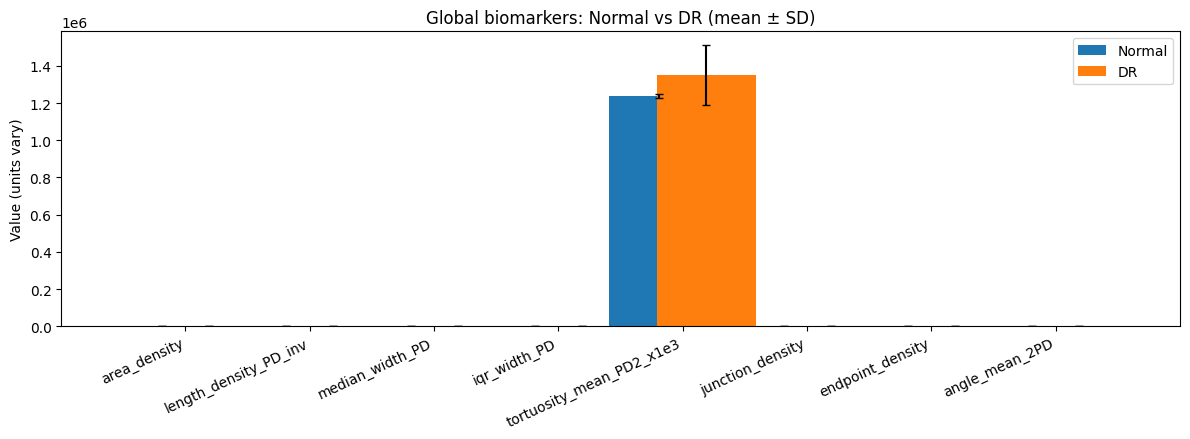

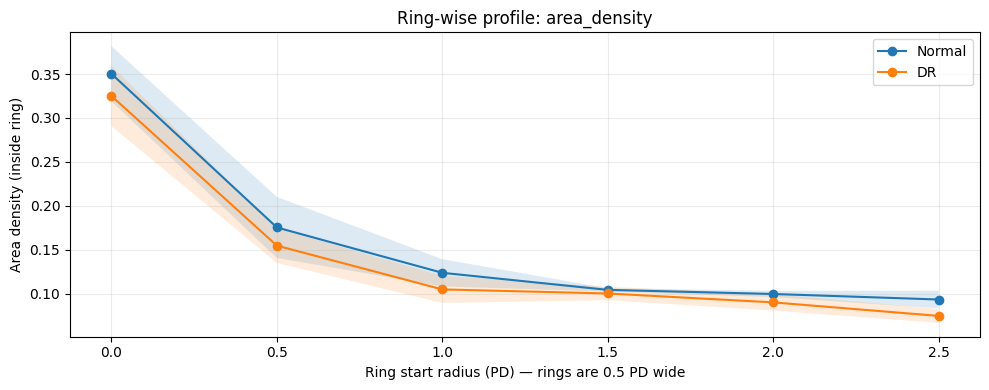

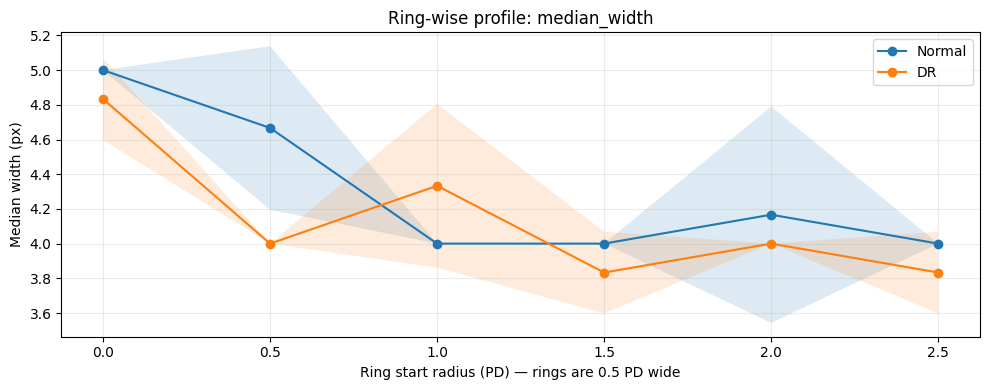

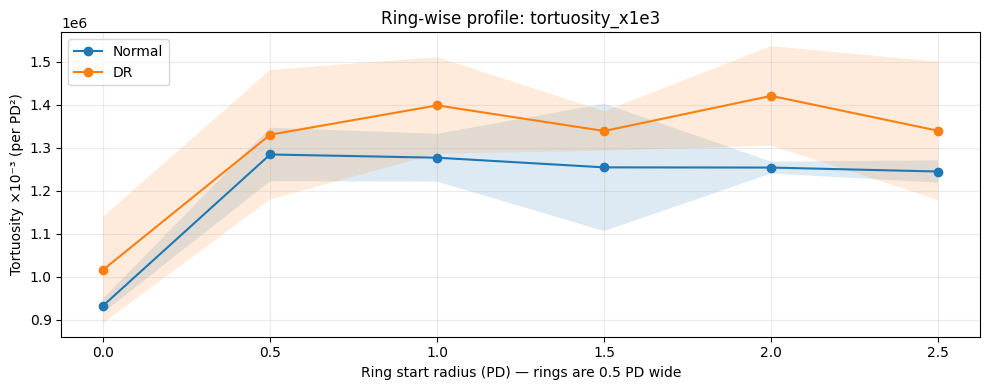

In [3]:
from src.retina_biomarkers.notebook_utils.pipeline.config import PipelineConfig
from src.retina_biomarkers.notebook_utils.pipeline.retina import run_pipeline
from src.retina_biomarkers.notebook_utils.report.compare import flatten_metrics, agg_compare, bar_compare, ring_profile, draw_overlay_ax

cfg = PipelineConfig()  # tweak if needed
ckpt_path = "../../outputs/checkpoints/final/[DRIVE] dpcn_refineEdge.pth"

normal_paths = [
    "../../data/raw/DRIVE/test/images/01_test.png",
    "../../data/raw/DRIVE/test/images/10_test.png",
    "../../data/raw/DRIVE/test/images/13_test.png",
]
dr_paths = [
    "../../data/raw/DRIVE/test/images/08_test.png",
    "../../data/raw/DRIVE/test/images/14_test.png",
    "../../data/raw/DRIVE/test/images/17_test.png",
]

def run_list(paths):
    outs=[]
    for p in paths:
        try: outs.append(run_pipeline(p, ckpt_path, cfg=cfg))
        except Exception as e: print(f"[warn] failed on {p}: {e}")
    return outs

outs_norm = run_list(normal_paths)
outs_dr   = run_list(dr_paths)

# overlays (2×3)
import matplotlib.pyplot as plt, numpy as np
fig, axs = plt.subplots(2, 3, figsize=(14, 9))
for i in range(3):
    draw_overlay_ax(axs[0, i], outs_norm[i], f"Normal {i+1}") if i < len(outs_norm) else axs[0, i].axis("off")
    draw_overlay_ax(axs[1, i], outs_dr[i],   f"DR {i+1}")     if i < len(outs_dr)   else axs[1, i].axis("off")
fig.suptitle("Vessels (green) + OD (red) + PD rings (white)", y=0.98)
plt.tight_layout(); plt.show()

# tabulate & compare
import pandas as pd
dfN = pd.DataFrame([flatten_metrics(o) for o in outs_norm])
dfD = pd.DataFrame([flatten_metrics(o) for o in outs_dr])

key_glob = [
    "area_density", "length_density_PD_inv",
    "median_width_PD", "iqr_width_PD",
    "tortuosity_mean_PD2_x1e3", "junction_density", "endpoint_density", "angle_mean_2PD"
]
comp_glob = agg_compare(dfN, dfD, key_glob)
display(comp_glob.round(4))

# bars
label_map = {
    "area_density": "Area density (0–1)",
    "length_density_PD_inv": "Len dens × PD²",
    "median_width_PD": "Median width / PD",
    "iqr_width_PD": "IQR width / PD",
    "tortuosity_mean_PD2_x1e3": "Tortuosity ×10⁻³ (per PD²)",
    "junction_density": "Junction density (px⁻²)",
    "endpoint_density": "Endpoint density (px⁻²)",
    "angle_mean_2PD": "Mean angle ≤2 PD (deg)",
}
bar_compare(dfN, dfD, key_glob, "Global biomarkers: Normal vs DR (mean ± SD)",
            ylabel="Value (units vary)")

# ring profiles (examples)
for metric, ylabel in [
    ("area_density",   "Area density (inside ring)"),
    ("median_width",   "Median width (px)"),
    ("tortuosity_x1e3","Tortuosity ×10⁻³ (per PD²)"),
]:
    xsN, A_N = ring_profile(dfN, metric)
    xsD, A_D = ring_profile(dfD, metric)
    xs = xsN if len(xsN)>=len(xsD) else xsD

    meanN, sdN = (A_N.mean(0), A_N.std(0)) if A_N.size else (np.array([]), np.array([]))
    meanD, sdD = (A_D.mean(0), A_D.std(0)) if A_D.size else (np.array([]), np.array([]))

    plt.figure(figsize=(10, 4))
    if meanN.size:
        plt.plot(xs, meanN, marker="o", label="Normal"); plt.fill_between(xs, meanN-sdN, meanN+sdN, alpha=0.15)
    if meanD.size:
        plt.plot(xs, meanD, marker="o", label="DR");     plt.fill_between(xs, meanD-sdD, meanD+sdD, alpha=0.15)
    plt.xlabel("Ring start radius (PD) — rings are 0.5 PD wide")
    plt.ylabel(ylabel); plt.title(f"Ring-wise profile: {metric}")
    plt.grid(alpha=0.25); plt.legend(); plt.tight_layout(); plt.show()


